# 05 Noise and Mapping Error Effects

This notebook separates four sources of apparent tuning change: deterministic gaze geometry, mapping error, SNR-limited estimation, and their combination. This separation is central because apparent PO instability is not automatically a biological retuning effect.

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from src.utils import load_config, rng_from_config
from src.sampling import sample_population
from src.natural_images import load_natural_images
from src.simulation import run_decomposition, SMALL_MAPPING_ERROR, perfect_mapping_config
from src.coordinate_mapping import mapping_error_field
from src.responses import grating_response_mean
from src.stimuli import make_grating_stimuli
from src.tuning import bootstrap_orientation_ci
from src.plotting import set_plot_style, plot_summary_bars

set_plot_style()
fig_dir = ROOT / 'results/figures'
fig_dir.mkdir(parents=True, exist_ok=True)

cfg = load_config(ROOT / 'configs/default.yaml', debug=True)
rng = rng_from_config(cfg)
pop = sample_population(cfg, rng)
images = load_natural_images(cfg, rng)
decomp = run_decomposition(pop, images, cfg, rng)
display(decomp.groupby('condition').tail(1))

,gaze_az_deg,gaze_el_deg,median_abs_delta_po_deg,p90_abs_delta_po_deg,fraction_abs_delta_po_gt_threshold,median_signed_delta_po_deg,median_circular_variance_change,median_tuning_strength_change,median_abs_tuning_strength_change,population_response_correlation,median_per_neuron_response_change,median_relative_response_change,fraction_large_response_change,rdm_similarity_to_baseline,image_discriminability,shifted_image_discriminability,condition,summary_radius
35,5.0,5.0,9.486046,37.275108,0.48125,2.291346,0.006686,-0.006686,0.078289,-0.084952,6.098013,1.019222,1.0,0.320354,0.990294,0.967564,gaze_only_perfect_noiseless,10.0
71,5.0,5.0,9.722081,35.255105,0.49375,1.264537,0.005612,-0.005612,0.079683,-0.088540,5.902217,1.012298,1.0,0.317431,0.990294,0.957443,gaze_plus_mapping_error_noiseless,10.0
107,5.0,5.0,10.006442,42.977859,0.50000,1.981971,0.019903,-0.019903,0.086256,-0.084798,6.078836,1.018369,1.0,0.320363,0.990898,0.967233,gaze_plus_noise_perfect,10.0
143,5.0,5.0,10.086753,37.505790,0.50000,0.706388,0.006273,-0.006273,0.100544,-0.088252,5.903670,1.010921,1.0,0.318799,0.990642,0.958164,gaze_plus_mapping_error_plus_noise,10.0


## Four-Way Decomposition

The comparison below keeps the model, population, and shifts fixed while toggling mapping error and output noise. The noiseless perfect-mapping condition is the geometric baseline.

In [2]:
edge = decomp.sort_values('summary_radius').groupby('condition').tail(1)
plot_summary_bars(edge, fig_dir / 'notebook05_decomposition_summary.png')

## Mapping Error Field

Mapping error is not random output noise. It creates systematic coordinate displacement across the visual field, which can alter phase and position estimates even before neuronal noise is added.

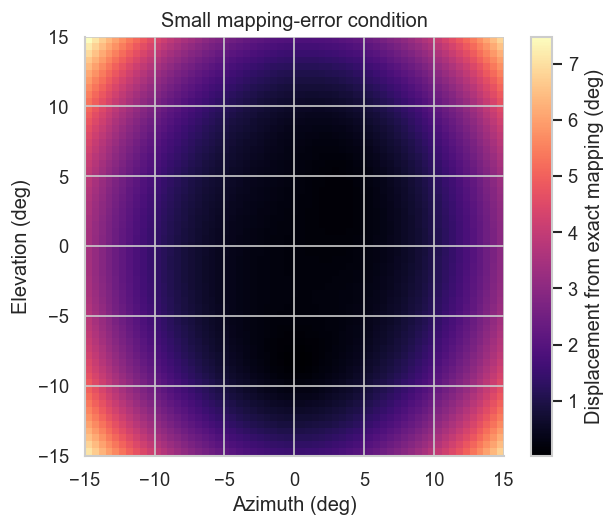

In [3]:
grid = np.linspace(-15, 15, 61)
aa, ee = np.meshgrid(grid, grid)
_, _, mag = mapping_error_field(aa, ee, SMALL_MAPPING_ERROR)
plt.figure(figsize=(5.5, 4.5))
plt.imshow(mag, extent=[grid.min(), grid.max(), grid.min(), grid.max()], origin='lower', cmap='magma')
plt.colorbar(label='Displacement from exact mapping (deg)')
plt.xlabel('Azimuth (deg)'); plt.ylabel('Elevation (deg)')
plt.title('Small mapping-error condition')
plt.tight_layout()
plt.savefig(fig_dir / 'notebook05_mapping_error_field.png', bbox_inches='tight')

## SNR and Bootstrap PO Uncertainty

Low SNR should broaden bootstrap uncertainty even if the deterministic model is unchanged. This is a direct check that apparent ΔPO can be an estimation problem.

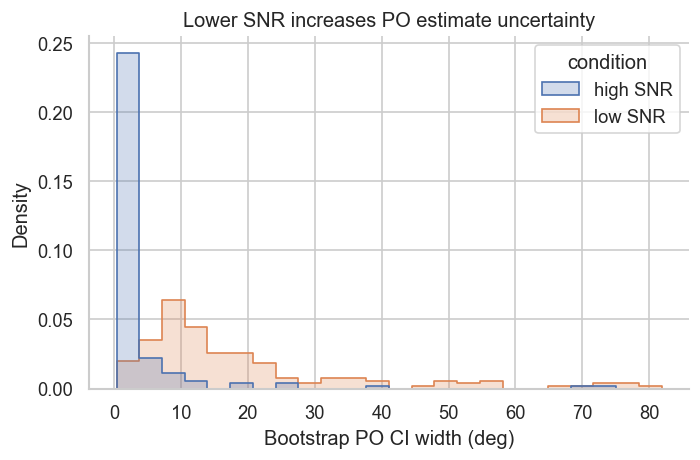

In [4]:
stim = make_grating_stimuli(cfg)
noise_conditions = {
    'high SNR': {'model': 'gaussian', 'repeats': 8, 'gaussian_sd': 0.025, 'clip_nonnegative': True},
    'low SNR': {'model': 'gaussian', 'repeats': 8, 'gaussian_sd': 0.22, 'clip_nonnegative': True},
}
ci_rows = []
for label, noise_cfg in noise_conditions.items():
    _, trials = grating_response_mean(pop, stim, cfg, rng, gaze_shift=(0, 0), mapping_config=perfect_mapping_config(), noise_config=noise_cfg, response_model='simple')
    ci = bootstrap_orientation_ci(trials, stim['orientations_deg'], stim['spatial_frequencies_cpd'], n_bootstrap=50, rng=rng)
    for width in ci['po_ci_width_deg']:
        ci_rows.append({'condition': label, 'po_ci_width_deg': width})
ci_df = pd.DataFrame(ci_rows)
plt.figure(figsize=(6, 4))
sns.histplot(data=ci_df, x='po_ci_width_deg', hue='condition', bins=24, element='step', stat='density', common_norm=False)
plt.xlabel('Bootstrap PO CI width (deg)')
plt.title('Lower SNR increases PO estimate uncertainty')
plt.tight_layout()
plt.savefig(fig_dir / 'notebook05_bootstrap_po_uncertainty.png', bbox_inches='tight')

## Takeaway

If low SNR alone produces wide PO uncertainty, apparent tuning drift should be interpreted cautiously. Mapping error is diagnosed by changes that appear in noiseless approximate-coordinate conditions. The strongest conclusions come from comparing all four conditions, not from a single heat map.